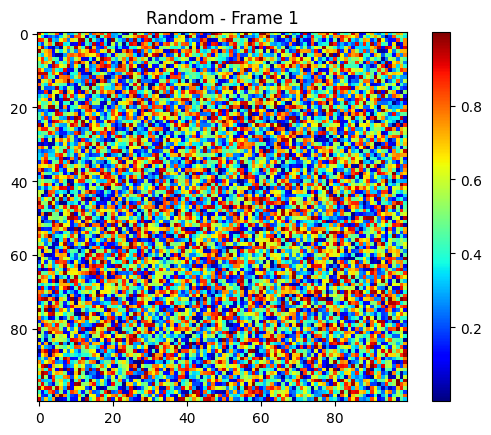

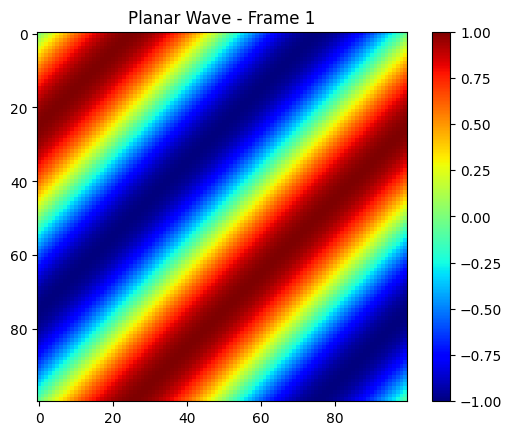

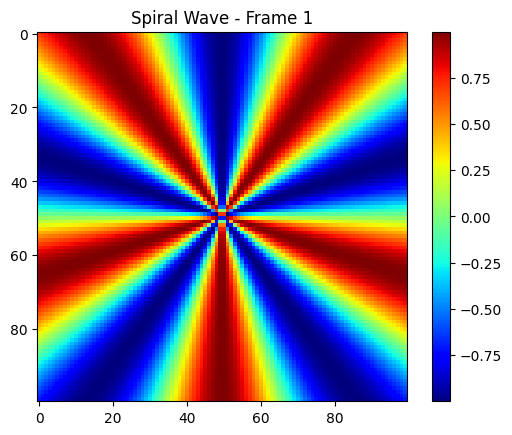

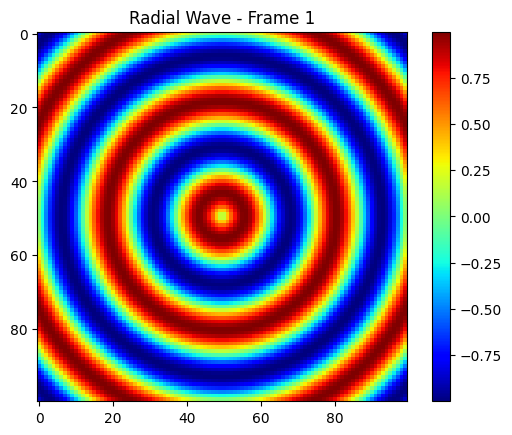

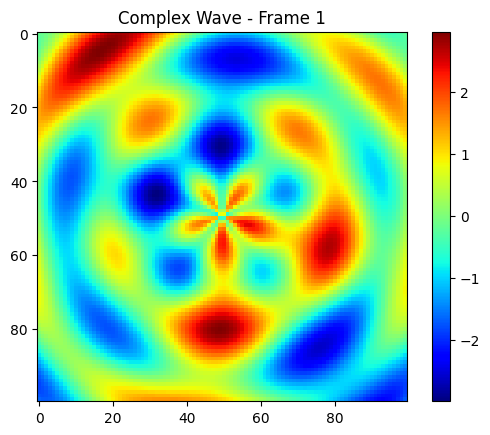

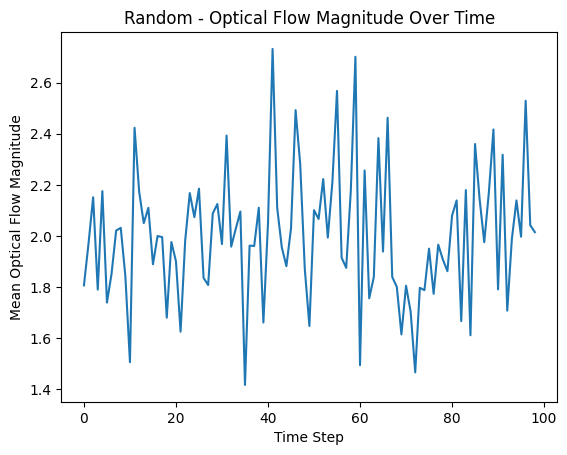

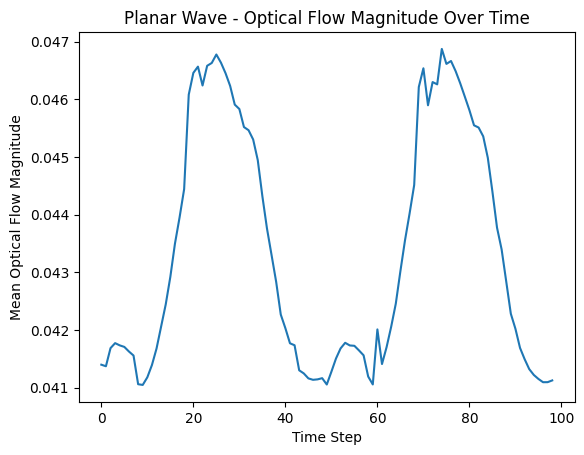

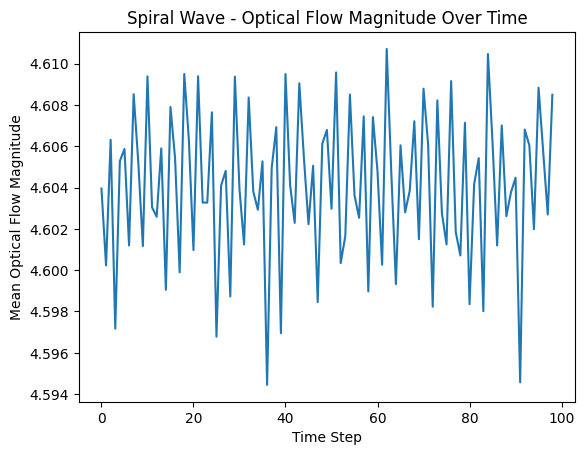

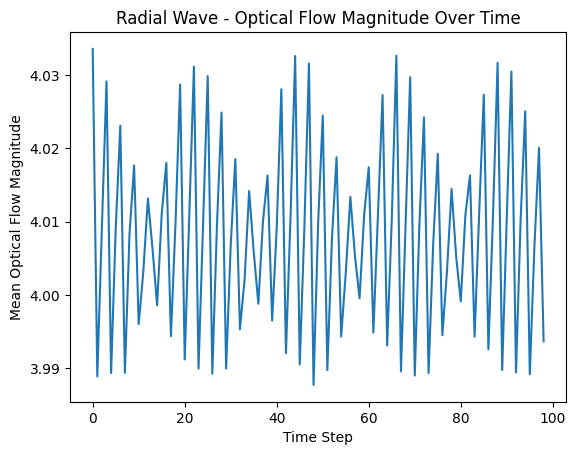

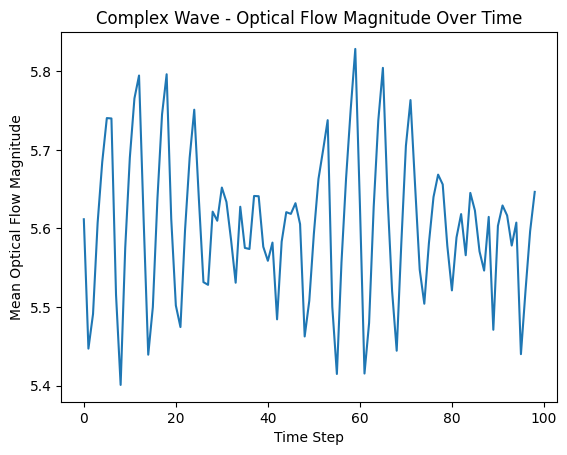

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def generate_random_pattern(size, t_steps):
    return np.random.rand(t_steps, size, size)

def generate_planar_wave(size, t_steps, speed=1):
    x = np.arange(size)
    y = np.arange(size)
    X, Y = np.meshgrid(x, y)
    pattern = np.zeros((t_steps, size, size))
    for t in range(t_steps):
        pattern[t] = np.sin((X + Y + t * speed) * 2 * np.pi / size)
    return pattern

def generate_spiral_wave(size, t_steps, speed=1):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)
    pattern = np.zeros((t_steps, size, size))
    for t in range(t_steps):
        pattern[t] = np.sin(5 * Theta + t * speed)
    return pattern

def generate_radial_wave(size, t_steps, speed=1):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    pattern = np.zeros((t_steps, size, size))
    for t in range(t_steps):
        pattern[t] = np.sin(R * 2 * np.pi + t * speed)
    return pattern

def generate_complex_wave(size, t_steps, speed=1):
    pattern = generate_spiral_wave(size, t_steps, speed) + generate_radial_wave(size, t_steps, speed) + generate_planar_wave(size, t_steps, speed)
    return pattern

# Simulate different patterns
size = 100
t_steps = 100
patterns = {
    "Random": generate_random_pattern(size, t_steps),
    "Planar Wave": generate_planar_wave(size, t_steps),
    "Spiral Wave": generate_spiral_wave(size, t_steps),
    "Radial Wave": generate_radial_wave(size, t_steps),
    "Complex Wave": generate_complex_wave(size, t_steps),
}

# Visualize some of the patterns
for name, pattern in patterns.items():
    plt.figure()
    plt.imshow(pattern[0], cmap='jet')
    plt.title(f'{name} - Frame 1')
    plt.colorbar()
    plt.show()

# Quantification using Optical Flow
def apply_optical_flow(prev_frame, next_frame):
    prev_frame = np.uint8(255 * (prev_frame - np.min(prev_frame)) / (np.max(prev_frame) - np.min(prev_frame)))
    next_frame = np.uint8(255 * (next_frame - np.min(next_frame)) / (np.max(next_frame) - np.min(next_frame)))
    
    flow = cv2.calcOpticalFlowFarneback(prev_frame, next_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    return mag, ang

# Quantify using Optical Flow for each pattern
for name, pattern in patterns.items():
    magnitudes = []
    for t in range(1, t_steps):
        prev_frame = pattern[t-1]
        next_frame = pattern[t]
        mag, ang = apply_optical_flow(prev_frame, next_frame)
        magnitudes.append(np.mean(mag))

    plt.figure()
    plt.plot(magnitudes)
    plt.title(f'{name} - Optical Flow Magnitude Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Mean Optical Flow Magnitude')
    plt.show()
